In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from tensorboard.data.proto.data_provider_pb2 import TensorData

Download dữ liệu chữ số viết tay MNIST

In [6]:
# Chuẩn bị dữ liệu
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Chuyển đổi sang định dạng float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
# Chuẩn hóa ảnh từ from [0, 255] to [0, 1].
print(type(x_train))
x_train, x_test = x_train / 255., x_test / 255.
x_train, x_test, y_train, y_test = torch.from_numpy(x_train), torch.from_numpy(x_test), torch.from_numpy(y_train).type(torch.LongTensor), torch.from_numpy(y_test).type(torch.LongTensor)

<class 'numpy.ndarray'>


In [11]:
print(type(x_train), x_train.shape)
print(type(y_train), y_train.shape)
print(type(x_test), x_test.shape)
print(type(y_test), y_test.shape)

print(y_test[:15])


<class 'torch.Tensor'> torch.Size([60000, 28, 28])
<class 'torch.Tensor'> torch.Size([60000])
<class 'torch.Tensor'> torch.Size([10000, 28, 28])
<class 'torch.Tensor'> torch.Size([10000])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1])


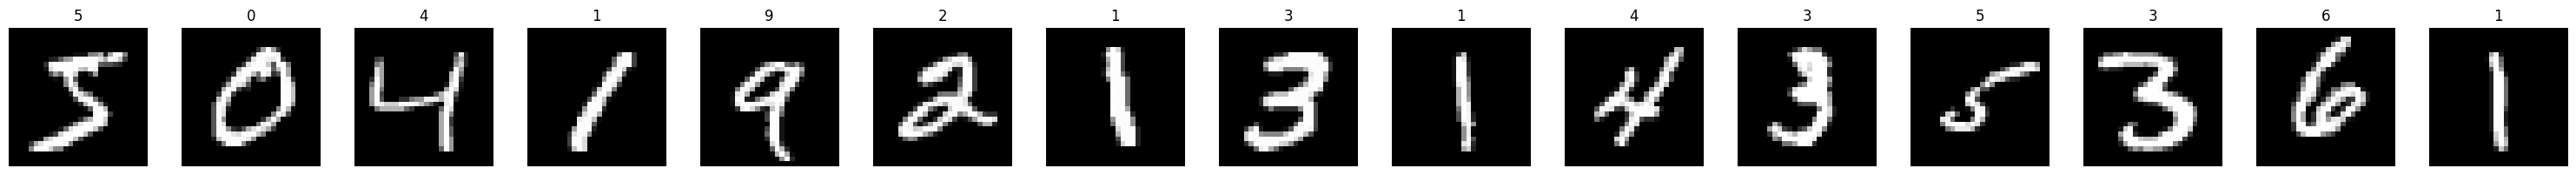

In [17]:
n = 15

fig, axes = plt.subplots(1, n, figsize=(n*2, 2))

for i in range(n):
    img = x_train[i].numpy()
    label = int(y_train[i].item())

    ax = axes[i]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 16
# trainloader = []
# for (i,j) in zip(x_train, y_train):
#     trainloader.append([i,j])

train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)

trainloader = DataLoader(train_ds, shuffle=True, batch_size=batch_size)

# testloader = []
# for (i,j) in zip(None, None):
#     testloader.append([i,j])
testloader = DataLoader(test_ds, shuffle=True, batch_size=batch_size)

In [25]:
print(trainloader)
print(trainloader.dataset[0])

(tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.000

In [8]:
num_features = 784 # 28 * 28
n_hidden_1 = 512
n_hidden_2 = 128
n_hidden_3 = 32
num_classes = 10

Sử dụng các tham số ở trên để xây dựng mô hình

In [19]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        """
        code
        """
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(num_features, n_hidden_1), nn.ReLU(),
            nn.Linear(n_hidden_1, n_hidden_2), nn.ReLU(),
            nn.Linear(n_hidden_2, n_hidden_3), nn.ReLU(),
            nn.Linear(n_hidden_3, num_classes)
        )

    def forward(self, x):
        """
        code
        """
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

net = Net()

In [27]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [31]:
for epoch in range(1):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # load input và labels
        inputs, labels = data #get 1 batch

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        # print(labels.shape)
        # print(outputs.shape)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 1000 == 0:    # print every 1000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 1000))
            running_loss = 0.0

print('Finished Training')

[1,     1] loss: 0.000
[1,  1001] loss: 0.226
[1,  2001] loss: 0.204
[1,  3001] loss: 0.181
Finished Training


In [33]:
correct = 0
total = 0
# do đang thực hiện việc dự đoán nên ko cần tính đạo hàm
with torch.no_grad():
    for data in testloader:
        inputs, labels = data
        # chạy hàm dự đoán
        outputs = net(inputs)
        # the class với giá trị xác suất cao nhất là đâu ra dự đoán
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 95 %


## Save and load model<br>
Trình bày 1 trong các các lưu model và load model trong PyTorch

1.   Lưu model<br>
```
torch.save(model.state_dict(), PATH)
```
trong đó PATH là đường dẫn tự định nghĩa
2.   Load model <br>

*   Trước tiên phải định nghĩa model trước. Model được định nghĩa phải giống hệt với model đã được lưu lại. Như ví dụ trong bài này, thì sẽ thực hiện như sau: 
```
model = Net()
```
*   Load trọng số đã được học vào mô hình<br>
```
model.load_state_dict(torch.load(PATH))
# vô hiệu hóa các layer như Dropout hay BatchNorm 
model.eval()
```
3. Có thể tham khảo thêm các phương pháp lưu và load model tại: https://pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html








In [34]:
PATH = "mnist_mlp.pth"
torch.save(net.state_dict(), PATH)

In [35]:
model = Net()
model.load_state_dict(torch.load(PATH))
model.eval()


correct = 0
total = 0
# do đang thực hiện việc dự đoán nên ko cần tính đạo hàm
with torch.no_grad():
    for data in testloader:
        inputs, labels = data
        # chạy hàm dự đoán
        outputs = model(inputs)
        # the class với giá trị xác suất cao nhất là đâu ra dự đoán
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 95 %
